In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import muon as mu
import matplotlib
import matplotlib.pyplot as plt
import warnings

/home/hwjeong/miniconda3/envs/project_md/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
# Suppress all downstream runtime and configuration warnings for a clean report
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
# 1. Set the directory path for RNA files (relative to the Jupyter notebook)
rna_dir = "data/rna"

# 2. Initialize an empty list to store individual sample AnnData objects
adata_list = []

# 3. Sort and loop through all .h5 files in the rna directory
all_files = sorted([f for f in os.listdir(rna_dir) if f.endswith('.h5')])

for file_name in all_files:
    print(f"Currently loading: {file_name}")
    
    # 3-1. Extract Sample ID and Experimental Condition (Group) from the filename
    parts = file_name.split('_')
    gsm_id = parts[0]       # e.g., "GSM8306593"
    sample_id = parts[1]    # e.g., "VM1", "MI7"
    group_id = "".join([char for char in sample_id if char.isalpha()]) # e.g., "VM", "MI"
    
    # 3-2. Load the single-cell RNA-seq data
    file_path = os.path.join(rna_dir, file_name)
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()
    
    # 3-3. Inject metadata for downstream analysis
    adata.obs['sample_id'] = sample_id
    adata.obs['group_id'] = group_id
    adata.obs['gsm_id'] = gsm_id
    
    # Append sample_id to barcodes to prevent duplicate names across 24 samples
    adata.obs_names = adata.obs_names + "-" + sample_id
    
    # Append the processed sample to the list
    adata_list.append(adata)

# 4. Concatenate the RNA data from all 24 samples into one object
# (join="inner" keeps only the genes present in all samples)
combined_rna = ad.concat(adata_list, join="inner")

# 5. Create a MuData container
mdata = mu.MuData({"rna": combined_rna})
mdata.var_names_make_unique()

print("\n=== Data Build Complete ===")
print(mdata)


Currently loading: GSM8306593_VM1_filtered_feature_bc_matrix.h5
Currently loading: GSM8306594_VM2_filtered_feature_bc_matrix.h5
Currently loading: GSM8306595_VM3_filtered_feature_bc_matrix.h5
Currently loading: GSM8306596_VM4_filtered_feature_bc_matrix.h5
Currently loading: GSM8306597_HC5_filtered_feature_bc_matrix.h5
Currently loading: GSM8306598_HC6_filtered_feature_bc_matrix.h5
Currently loading: GSM8306599_MI7_filtered_feature_bc_matrix.h5
Currently loading: GSM8306600_MI8_filtered_feature_bc_matrix.h5
Currently loading: GSM8306601_MD9_filtered_feature_bc_matrix.h5
Currently loading: GSM8306602_MD10_filtered_feature_bc_matrix.h5
Currently loading: GSM8306603_MD11_filtered_feature_bc_matrix.h5
Currently loading: GSM8306604_MD12_filtered_feature_bc_matrix.h5
Currently loading: GSM8306605_VM13_filtered_feature_bc_matrix.h5
Currently loading: GSM8306606_MI14_filtered_feature_bc_matrix.h5
Currently loading: GSM8306607_MD15_filtered_feature_bc_matrix.h5
Currently loading: GSM8306608_MI16

In [4]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 74719 × 36601
    obs: 'sample_id', 'group_id', 'gsm_id'

In [5]:
rna.var['mt'] = rna.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [6]:
print(rna.obs.head())
print(rna.var.head())

                       sample_id group_id      gsm_id  n_genes_by_counts  \
AAACAGCCAATATACC-1-VM1       VM1       VM  GSM8306593               2086   
AAACATGCATCCCTCA-1-VM1       VM1       VM  GSM8306593               1025   
AAACCAACACTAAGTT-1-VM1       VM1       VM  GSM8306593               1525   
AAACCGAAGAATCTCA-1-VM1       VM1       VM  GSM8306593                841   
AAACCGGCATACCCGG-1-VM1       VM1       VM  GSM8306593                687   

                        total_counts  total_counts_mt  pct_counts_mt  
AAACAGCCAATATACC-1-VM1        4091.0            234.0       5.719873  
AAACATGCATCCCTCA-1-VM1        1574.0             54.0       3.430750  
AAACCAACACTAAGTT-1-VM1        2514.0             62.0       2.466189  
AAACCGAAGAATCTCA-1-VM1        1231.0             59.0       4.792851  
AAACCGGCATACCCGG-1-VM1         959.0             27.0       2.815433  
                mt  n_cells_by_counts  mean_counts  pct_dropout_by_counts  \
MIR1302-2HG  False                  1   

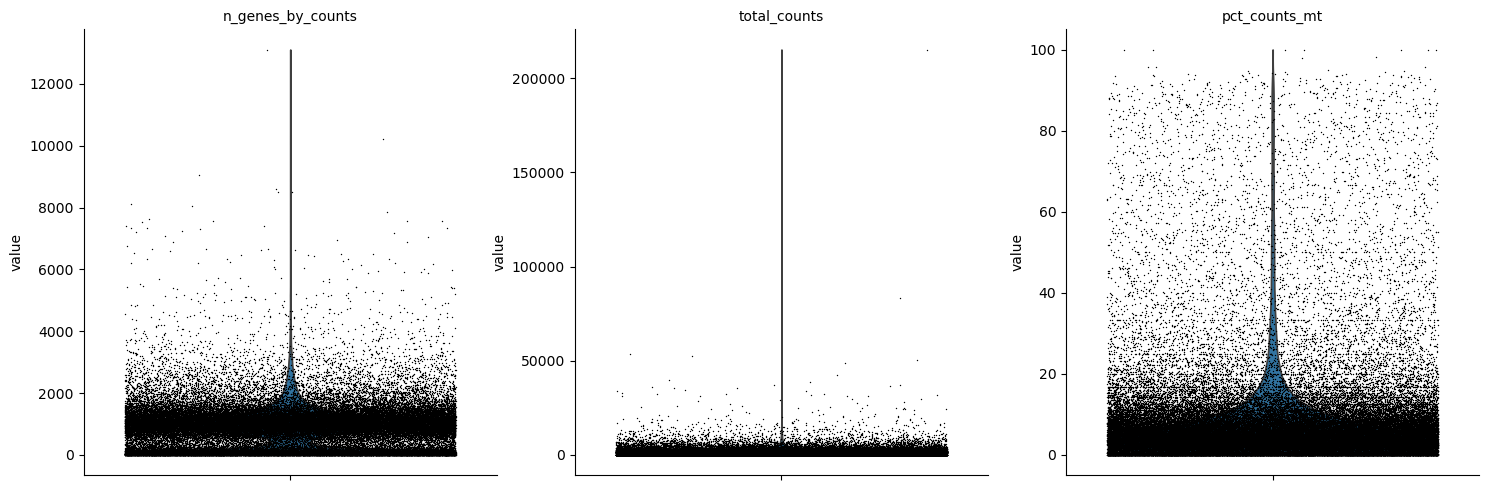

In [7]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [8]:
# Filter genes that are expressed in at least 3 cells

mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= 3)
# This is analogous to
#   sc.pp.filter_genes(rna, min_cells=3)
# but does in-place filtering and avoids copying the object

In [9]:
# Filter cells

mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 5000))
# This is analogous to
#   sc.pp.filter_cells(rna, min_genes=200)
#   rna = rna[rna.obs.n_genes_by_counts < 5000, :]
# but does in-place filtering avoiding copying the object

mu.pp.filter_obs(rna, 'total_counts', lambda x: x < 15000)
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

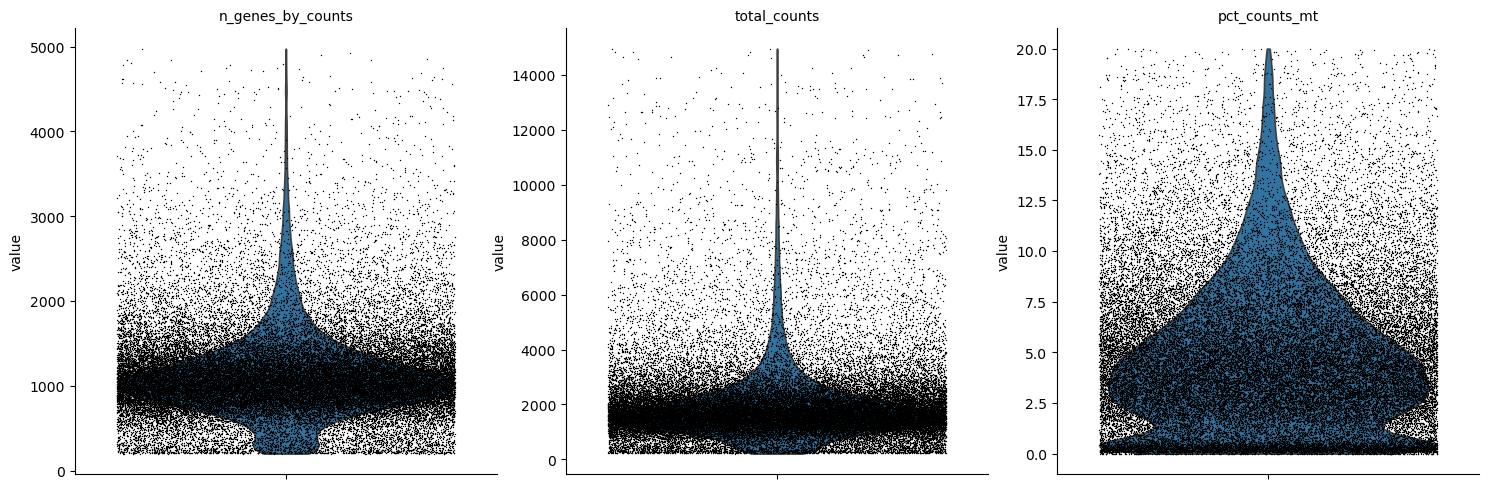

In [10]:
# Violin plots after filtering

sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

### Normalization

In [11]:
# Inter-sample normalization and log transformation
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

### Feature Selection

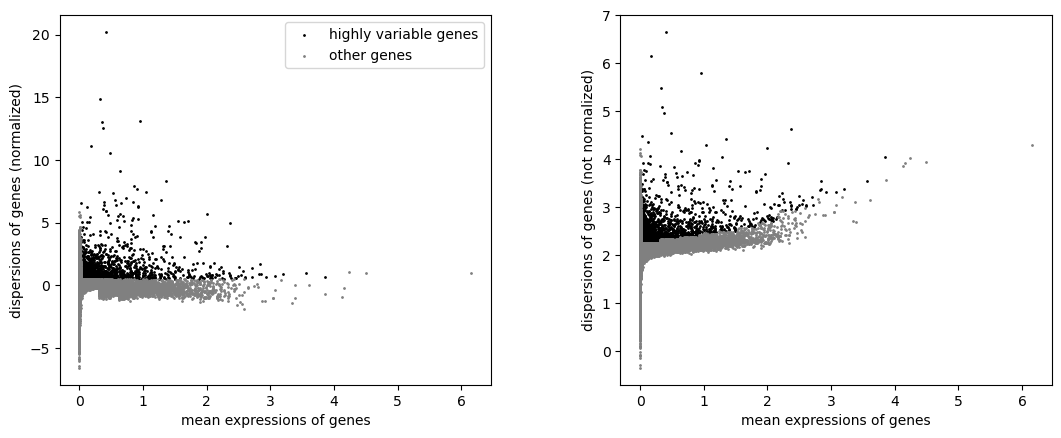

In [12]:
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)
sc.pl.highly_variable_genes(rna)

In [13]:
print(np.sum(rna.var.highly_variable))

2699


### Scaling

In [14]:
rna.raw = rna   # log-normalized counts are stored in .raw slot

# Z-scaling
sc.pp.scale(rna, max_value=10)

## Analysis

### PCA and neighbourhood graph

In [15]:
sc.tl.pca(rna, svd_solver='arpack')

Markers for T cells and NK cells (CD2), B cells (CD79A), monocytes (KLF4), and dendritic cells (IRF8) are used, where lymphoid includes T, B, NK cells and myeloid include monocytes.

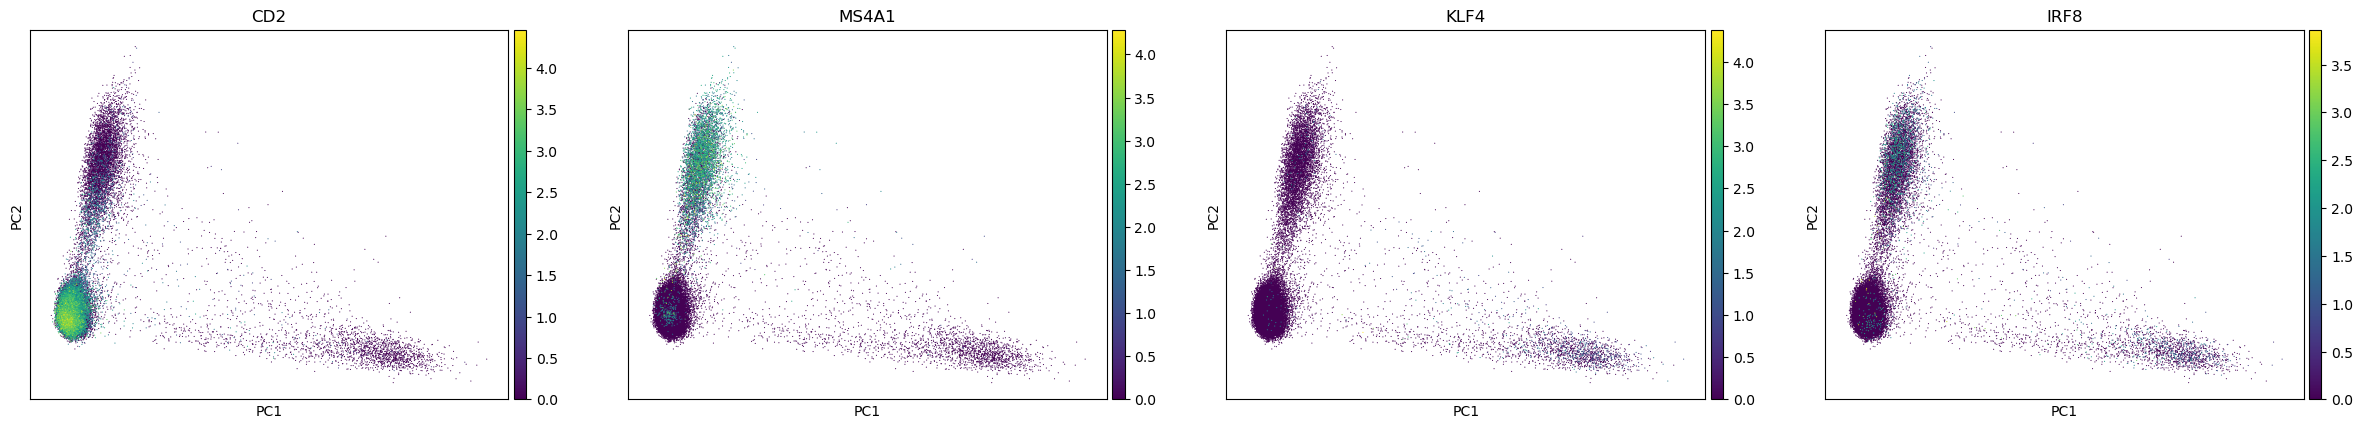

In [16]:
sc.pl.pca(rna, color=['CD2', 'MS4A1', 'KLF4', 'IRF8'])

There is almost no detection of monocytes, and dendritic cells are clustered together with B cells. We cannot conclude what PC1 does in this plot, but we can say that PC2 separates T & NK cells from B cells. 

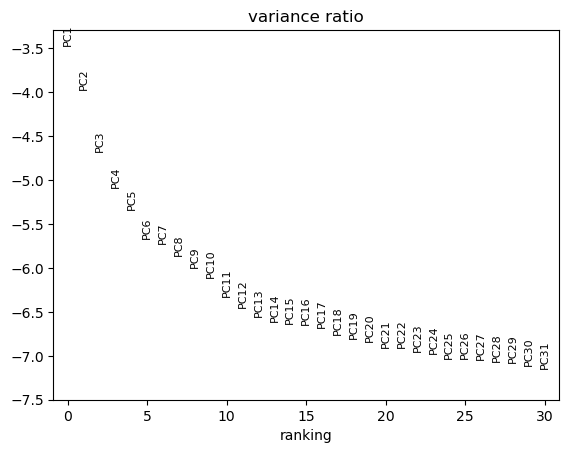

In [17]:
sc.pl.pca_variance_ratio(rna, log=True)

In [18]:
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)

In [19]:
sc.tl.leiden(mdata["rna"], resolution=0.5, flavor="igraph", n_iterations=2, directed=False)

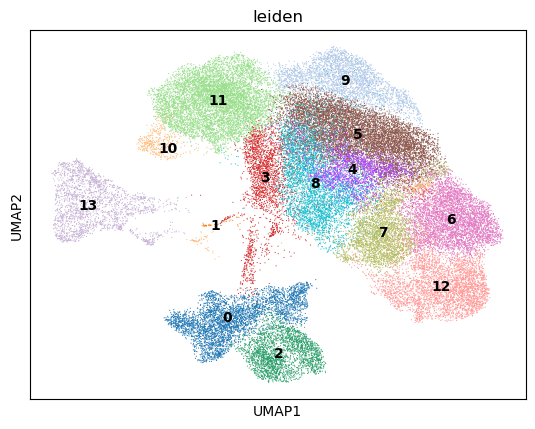

In [20]:
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)
sc.pl.umap(rna, color="leiden", legend_loc="on data")

### Marker genes and cell types

In [21]:
sc.tl.rank_genes_groups(rna, 'leiden', method='t-test')

In [22]:
result = rna.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.set_option('display.max_columns', 50)
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'pvals']}).head(10)

df

,0_n,0_p,1_n,1_p,2_n,2_p,3_n,3_p,4_n,4_p,5_n,5_p,6_n,6_p,7_n,7_p,8_n,8_p,9_n,9_p,10_n,10_p,11_n,11_p,12_n,12_p,13_n,13_p
0,BANK1,0.0,ZBTB20,2.144490e-13,AFF3,0.0,FP236383.3,0.000004,UTY,0.000000e+00,CCSER2,0.0,CAMK4,0.0,IL7R,0.0,RPL13A,0.0,CCL5,0.0,PDE7B,3.373475e-128,AOAH,0.0,CAMK4,0.0,RAPGEF1,0.0
1,AFF3,0.0,CTNNA3,2.342832e-12,IGHM,0.0,RBFOX1,0.000123,PRKY,0.000000e+00,RABGAP1L,0.0,ANK3,0.0,TPT1,0.0,TMSB4X,0.0,RPL13A,0.0,MAML3,1.430117e-105,CD247,0.0,LEF1,0.0,ASAP1,0.0
2,ARHGAP24,0.0,FOXP1,5.730472e-11,BACH2,0.0,AC034268.2,0.001536,CCL5,0.000000e+00,AOAH,0.0,IL7R,0.0,RPL13,0.0,CCL5,0.0,TMSB10,0.0,LINC00996,2.382131e-102,MCTP2,0.0,FOXP1,0.0,SLC7A11,0.0
3,EBF1,0.0,SKAP1,4.292511e-09,BANK1,0.0,AD000090.1,0.003797,MT-ATP6,0.000000e+00,C1orf21,0.0,ARHGAP15,0.0,CAMK4,0.0,RPS27,0.0,RPL23A,0.0,ATP8B4,9.048113e-91,GNLY,0.0,PRKCA,0.0,NEAT1,0.0
4,RALGPS2,0.0,PTPRD,1.610558e-08,ARHGAP24,0.0,MTRNR2L1,0.006804,MT-CO1,0.000000e+00,ZBTB20,0.0,PDE3B,0.0,RPL13A,0.0,RPL13,0.0,TMSB4X,0.0,IKZF2,2.420286e-85,PLCB1,0.0,MAML2,0.0,RBM47,0.0
5,CD74,0.0,LRP1B,2.501562e-08,SIPA1L1,0.0,MTRNR2L12,0.010583,USP9Y,1.889670e-302,PTPRC,0.0,SERINC5,0.0,RPL32,0.0,RPL23A,0.0,RPL19,0.0,AHI1,3.983399e-76,UTRN,0.0,SERINC5,0.0,CDK14,0.0
6,SESN3,0.0,DLG2,2.847241e-08,PRKCE,0.0,ROR1-AS1,0.017273,MT-ND3,9.399573e-269,CCL5,0.0,INPP4B,0.0,RPL19,0.0,RPLP2,0.0,AOAH,0.0,NCALD,2.014880e-67,BNC2,0.0,NELL2,0.0,PLXDC2,0.0
7,PALM2-AKAP2,0.0,DMD,3.046002e-08,ACSM3,0.0,LSAMP,0.020224,MT-CO3,7.650624e-269,PRKCH,0.0,CSGALNACT1,0.0,RPS27A,0.0,RPL41,0.0,RPS11,0.0,BACH2,9.037182e-63,LINC00996,0.0,PDE3B,0.0,ALCAM,0.0
8,MS4A1,0.0,CSMD3,5.382066e-08,CD74,0.0,CDH4,0.024093,CCSER2,5.802442e-241,FYN,0.0,PRKCA,0.0,EEF1A1,0.0,TPT1,0.0,HLA-B,0.0,AL138828.1,6.045639e-57,KLRD1,0.0,FHIT,0.0,MITF,0.0
9,MEF2C,0.0,DPP10,5.430121e-08,COL19A1,0.0,ZFPM2,0.025761,MT-CO2,8.141119e-246,ZEB2,0.0,NELL2,0.0,RPS6,0.0,MT-ND3,0.0,RPL13,0.0,SRGAP3,8.783096e-55,PITPNC1,0.0,BCL11B,0.0,RASAL2,0.0


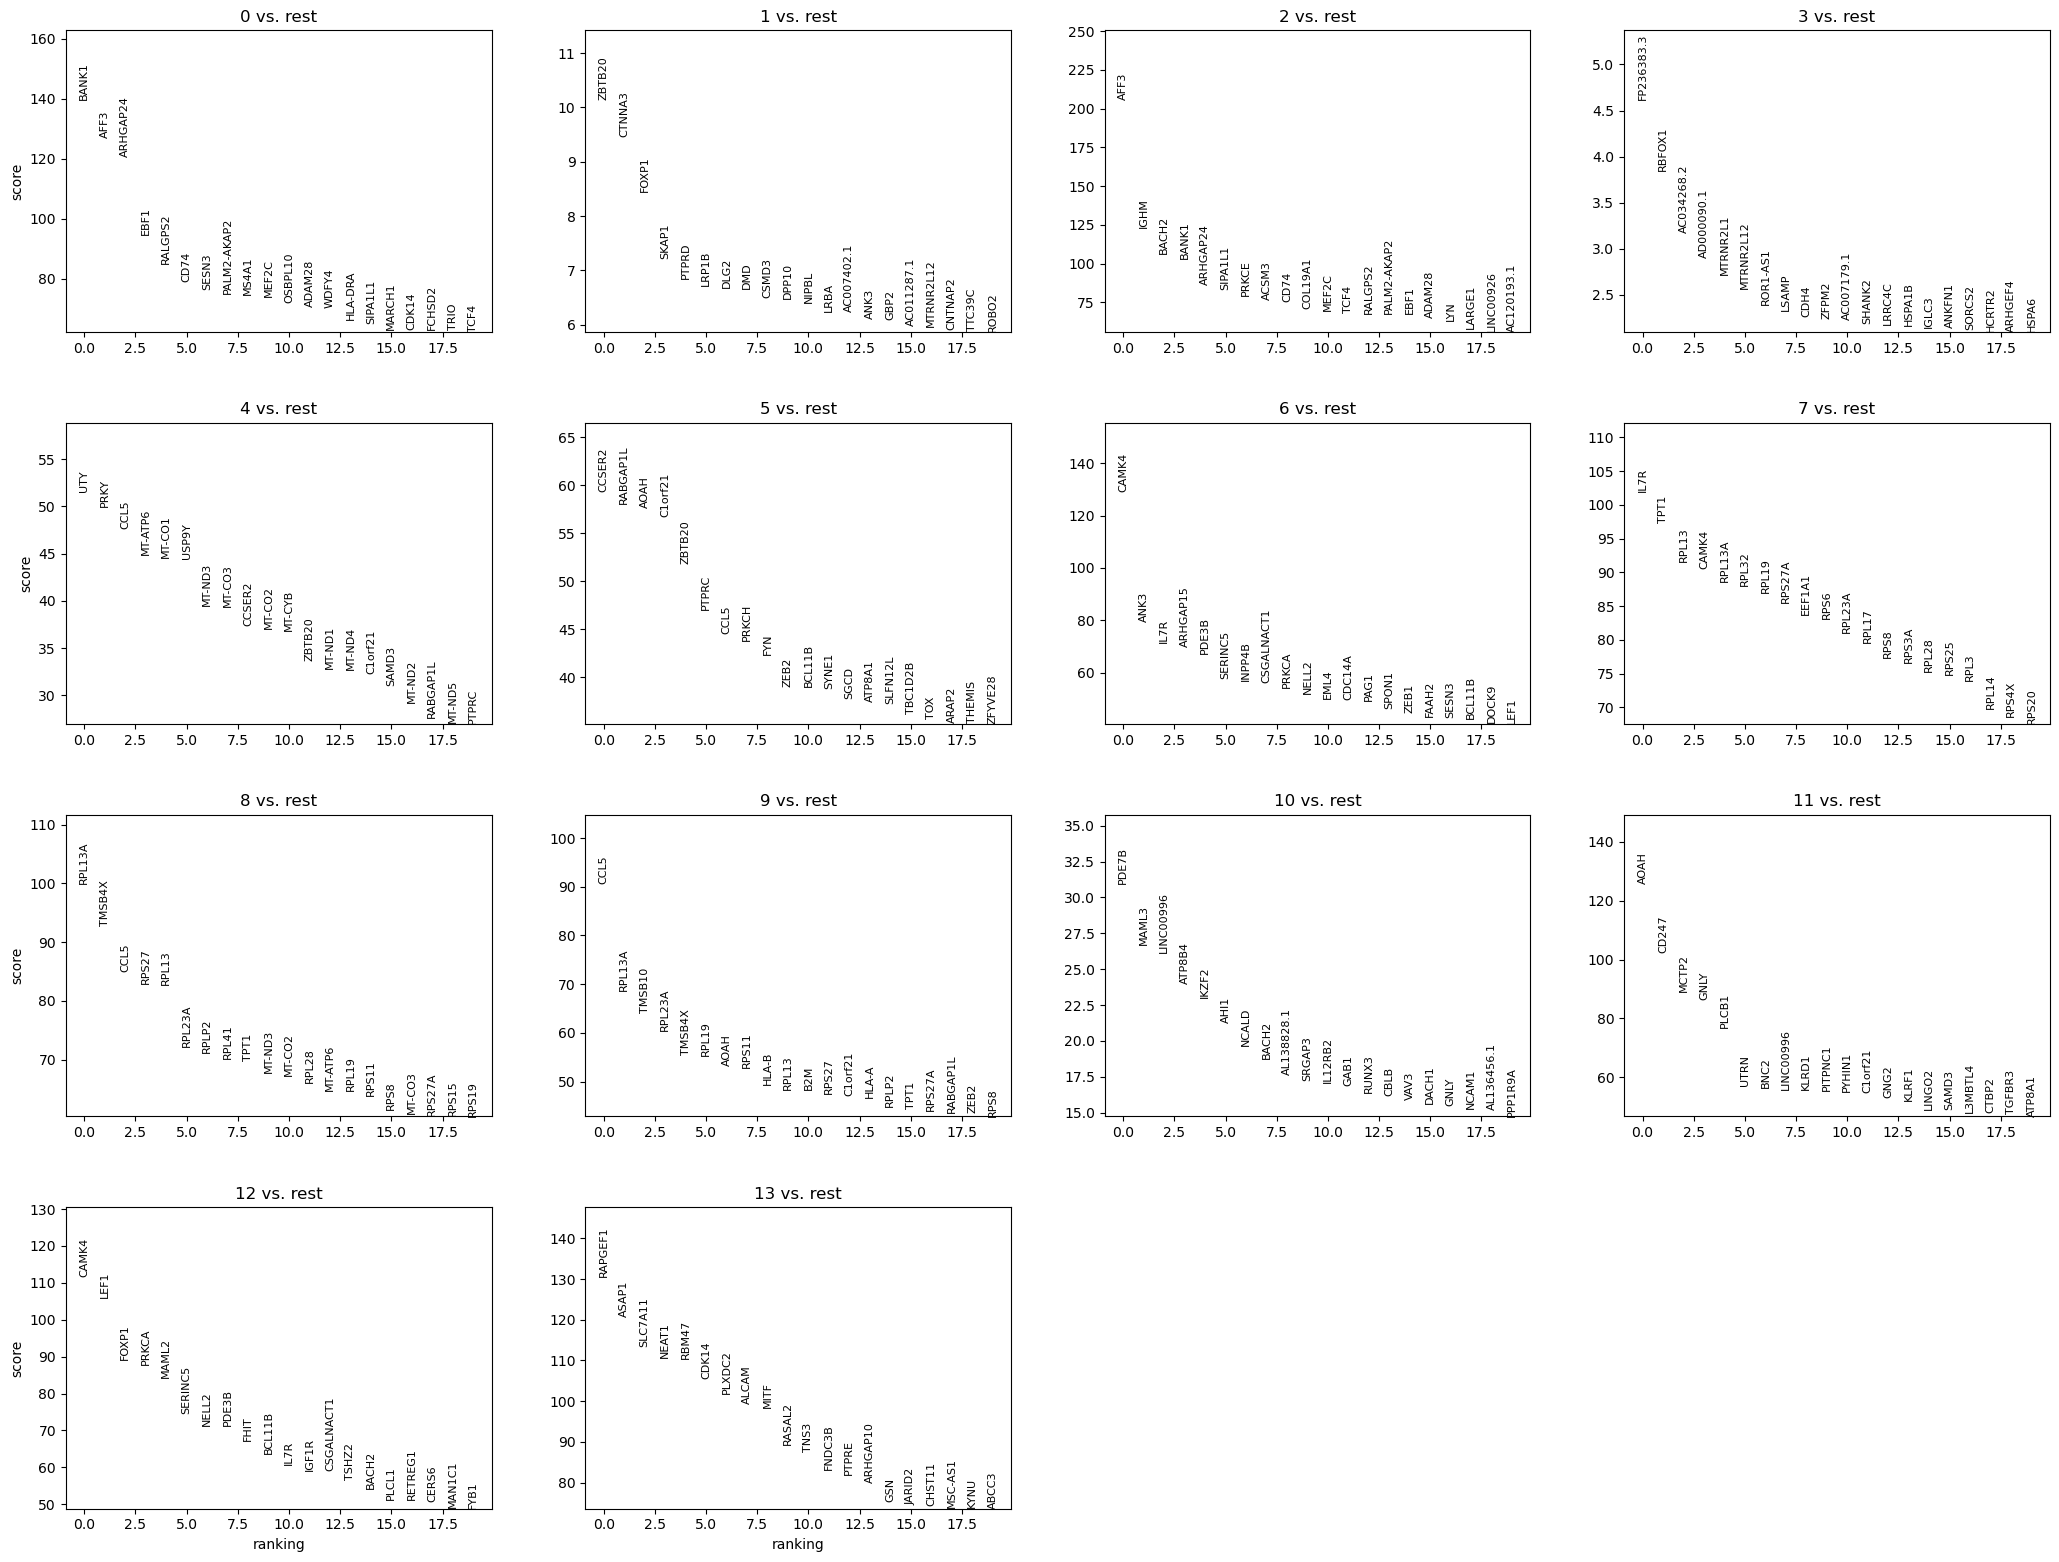

In [23]:
sc.pl.rank_genes_groups(rna, n_genes=20, sharey=False)

In [24]:
rna.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 47770 × 29713
    obs: 'sample_id', 'group_id', 'gsm_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'>

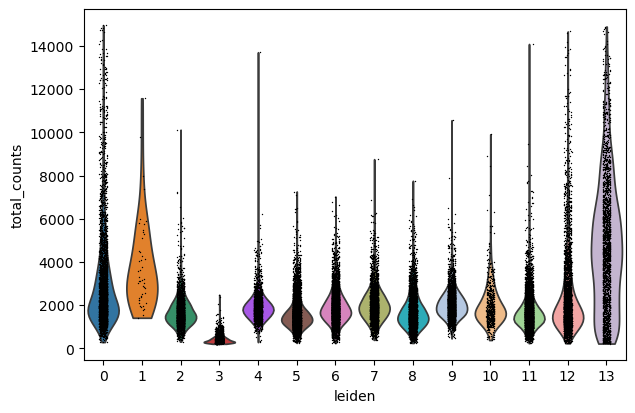

In [25]:
sc.pl.violin(rna, keys="total_counts", groupby="leiden")

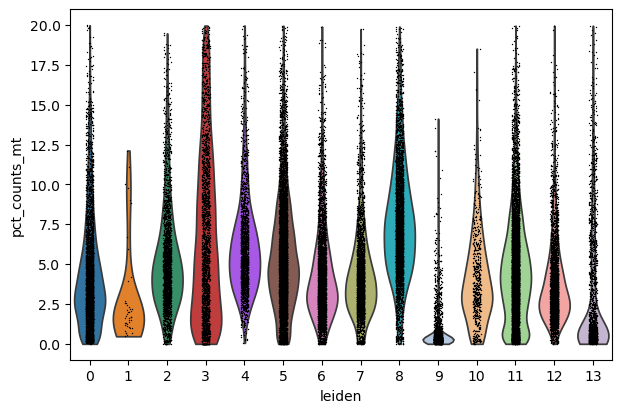

In [26]:
sc.pl.violin(rna, keys="pct_counts_mt", groupby="leiden")

In [27]:
cluster_9_df = sc.get.rank_genes_groups_df(rna, group="9")
target_genes = ["CD3D", "TRAC", "NKG7", "CD8A", "CD8B"]
check_result = cluster_9_df[cluster_9_df["names"].isin(target_genes)]
print(check_result)

    names     scores  logfoldchanges          pvals      pvals_adj
60   NKG7  29.227392        1.866252  5.014058e-167  7.524379e-165
98   CD3D  25.067221        1.680584  6.218899e-127  6.623015e-125
100  CD8A  24.716839        1.896498  1.234660e-123  1.278239e-121
103  CD8B  24.182962        2.174476  1.020967e-118  1.028339e-116
166  TRAC  19.209333        1.269239   4.999153e-78   3.315621e-76


Cluster 4 was excluded due to strong mitochondrial gene expression together with dominant sex-linked transcripts (including UTY, PRKY, and USP9Y), indicating a cluster primarily driven by donor-specific and technical effects rather than a coherent immune transcriptional program. In contrast, Cluster 9 was initially flagged as a potential doublet due to a mixed marker profile. However, subsequent quality control assessment showed normal total UMI counts and mitochondrial gene percentages, suggesting no evidence of low-quality cells. To further clarify its identity, additional marker gene analysis was performed, revealing a strong cytotoxic CD8 T cell signature characterized by CD3D, TRAC, CD8A, CD8B, and NKG7, confirming Cluster 9 as a biologically valid effector T cell population retained for downstream analysis.

In [28]:
mu.pp.filter_obs(rna, "leiden", lambda x: ~x.isin(["4"]))

In [29]:
print(rna.obs["leiden"].value_counts())

leiden
5     7961
11    7276
6     4434
8     4348
0     3888
12    3871
7     3168
9     3023
2     2487
3     2455
13    2171
10     626
1       47
4        0
Name: count, dtype: int64


In [30]:
new_cluster_names = {
    # [B cell lineage]
    "0": "B cells (Memory/Activated)",
    "2": "B cells (Naïve)",

    # [CD4 T / Naive T lineage]
    "6": "CD4+ T cells (Central Memory-like)",
    "7": "Naïve T cells",
    "12": "Naïve CD4+ T cells",

    # [T cell activation / mixed state]
    "13": "Activated / Stress-associated T cells",
    "1": "T cells (Transitional state)",

    # [Cytotoxic lineage]
    "9": "Cytotoxic CD8+ T cells",
    "8": "T cells (Ribosomal-high)",

    # [Myeloid lineage - Adjusted for conservative annotation]
    "5": "Monocytes (AOAH-high / Intermediate-like)",
    "10": "Dendritic cells / Monocyte-like (Putative)",
    "11": "Classical Monocytes",

    # [Unassigned State]
    "3": "Low-confidence / Unassigned cells",
}

rna.obs['celltype'] = rna.obs.leiden.astype("str").values
rna.obs.celltype = rna.obs.celltype.astype("category")
rna.obs.celltype = rna.obs.celltype.cat.rename_categories(new_cluster_names)

In [31]:
# Re-order categories for the next plots

rna.obs.celltype = rna.obs.celltype.cat.reorder_categories([
    'B cells (Naïve)', 'B cells (Memory/Activated)',
    'Naïve T cells', 'CD4+ T cells (Central Memory-like)', 'Naïve CD4+ T cells',
    'T cells (Transitional state)', 'Activated / Stress-associated T cells',
    'Cytotoxic CD8+ T cells', 'T cells (Ribosomal-high)',
    'Classical Monocytes', 'Monocytes (AOAH-high / Intermediate-like)', 'Dendritic cells / Monocyte-like (Putative)',
    'Low-confidence / Unassigned cells'
])

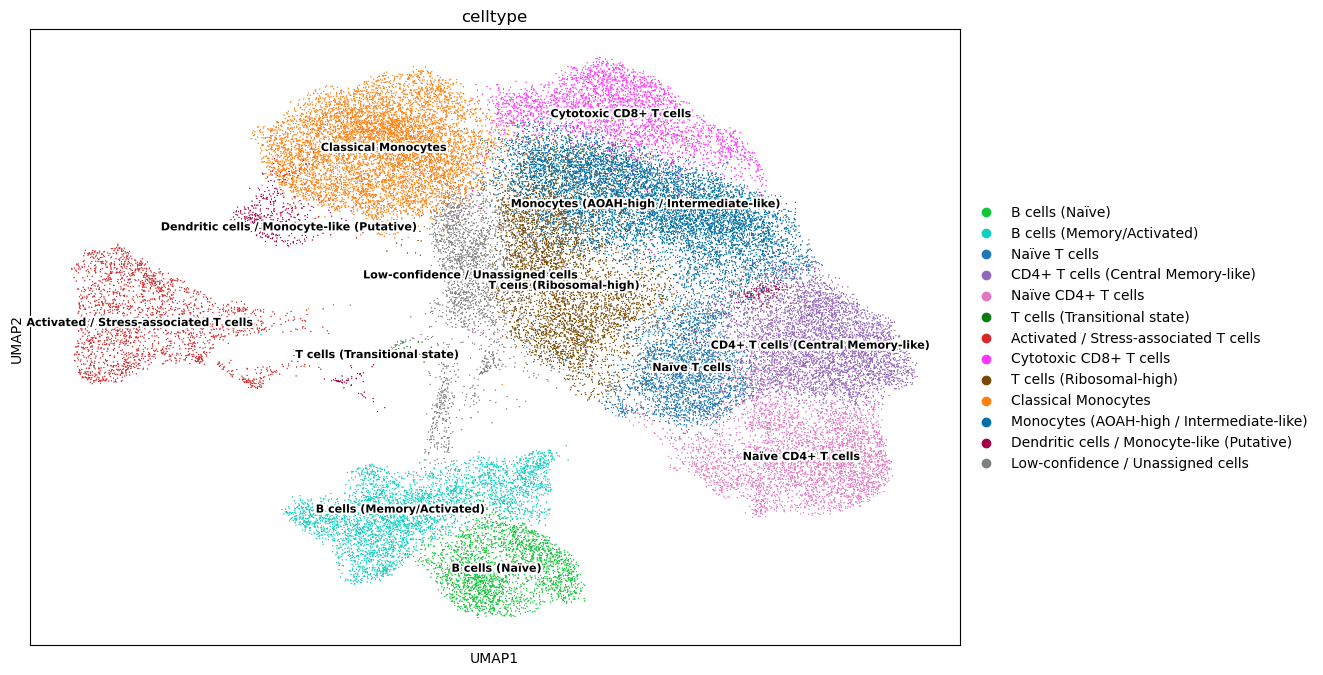

In [34]:
# 1. Initialize matplotlib figure and axes
fig, ax = plt.subplots(figsize=(12, 8))

my_color = [
    "#11c638", "#0fcfc0",  # B cells
    "#1f77b4", "#9467bd", "#e377c2",  # CD4 / Naive T cells
    "#077C11FF", "#d62728",  # Transitional / Activated T cells 
    "#ff34ff", "#7a4900",  # Cytotoxic & Ribosomal T cells
    "#ff7f0e", "#006fa6",  # Monocytes
    "#a30047",             # Dendritic cells
    "#7f7f7f"              # Low-confidence / Unassigned
]

# 2. First pass: Draw the UMAP with the right-side margin legend
sc.pl.umap(
    rna, 
    color="celltype", 
    palette=my_color[:len(rna.obs.celltype.cat.categories)],
    legend_loc="right margin",    # Generates the right legend box
    legend_fontsize=10,
    ax=ax,
    show=False
)

# 3. Second pass: Overlay the cluster names directly ON top of the cells
sc.pl.umap(
    rna, 
    color="celltype", 
    legend_loc="on data",         # Places text exactly on the cluster centers
    legend_fontsize=8,
    legend_fontoutline=3,         # Thick white stroke to stop letters from melting into dots
    ax=ax,
    show=False
)

# 4. Display the dual-legend composite plot
plt.show()

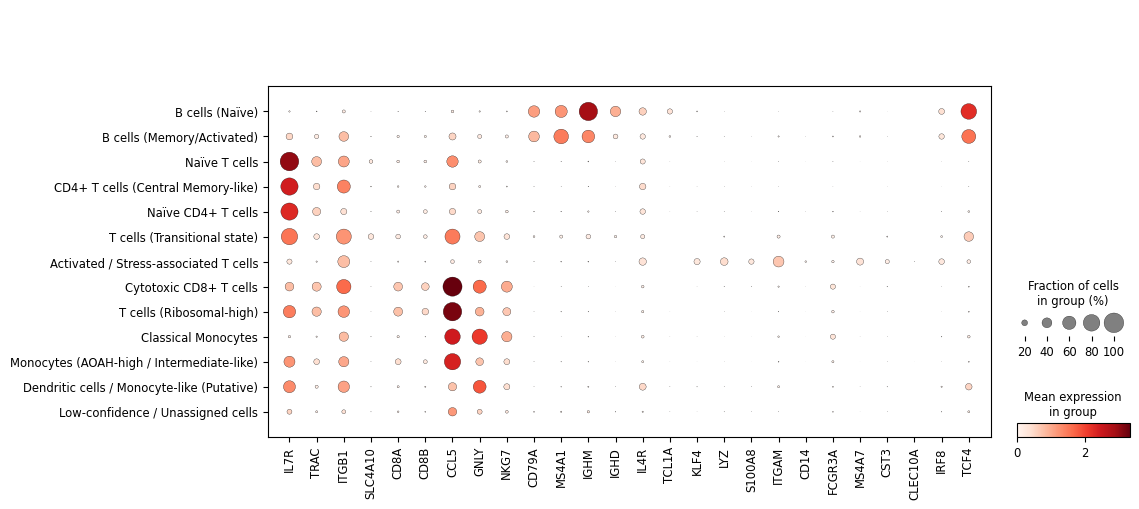

In [35]:
marker_genes = ['IL7R', 'TRAC',
                'ITGB1', # CD29
                'SLC4A10',
                'CD8A', 'CD8B', 'CCL5',
                'GNLY', 'NKG7',
                'CD79A', 'MS4A1', 'IGHM', 'IGHD',
                'IL4R', 'TCL1A',
                'KLF4', 'LYZ', 'S100A8', 'ITGAM', # CD11b
                'CD14', 'FCGR3A', 'MS4A7',
                'CST3', 'CLEC10A', 'IRF8', 'TCF4']

sc.pl.dotplot(rna, marker_genes, groupby='celltype');

In [36]:
print(rna.obs['sample_id'].value_counts())

sample_id
MI14    4946
MI16    3862
HC22    3611
HC21    3415
HC6     3114
MI8     3103
MD12    2983
MD11    2608
MD24    2297
VM13    1820
VM1     1790
VM2     1620
MD15    1363
MD10    1362
MI7     1360
VM3     1340
MD18    1174
MD17     894
HC19     813
HC5      753
MD9      607
MI23     487
VM4      433
HC20       0
Name: count, dtype: int64


After strict cell-level QC filtering, sample HC20 was completely discarded due to low cell quality (p. 3). Consequently, downstream analyses will be performed using the remaining 23 high-quality samples.

In [37]:
rna.obs['celltype'].value_counts()

celltype
Monocytes (AOAH-high / Intermediate-like)     7961
Classical Monocytes                           7276
CD4+ T cells (Central Memory-like)            4434
T cells (Ribosomal-high)                      4348
B cells (Memory/Activated)                    3888
Naïve CD4+ T cells                            3871
Naïve T cells                                 3168
Cytotoxic CD8+ T cells                        3023
B cells (Naïve)                               2487
Low-confidence / Unassigned cells             2455
Activated / Stress-associated T cells         2171
Dendritic cells / Monocyte-like (Putative)     626
T cells (Transitional state)                    47
Name: count, dtype: int64

In [40]:
sample_celltype_table = pd.crosstab(rna.obs['sample_id'], rna.obs['celltype'])
sample_celltype_table

celltype,B cells (Naïve),B cells (Memory/Activated),Naïve T cells,CD4+ T cells (Central Memory-like),Naïve CD4+ T cells,T cells (Transitional state),Activated / Stress-associated T cells,Cytotoxic CD8+ T cells,T cells (Ribosomal-high),Classical Monocytes,Monocytes (AOAH-high / Intermediate-like),Dendritic cells / Monocyte-like (Putative),Low-confidence / Unassigned cells
sample_id,,,,,,,,,,,,,
HC5,6,85,3,1,0,0,202,225,72,97,18,14,30
HC6,16,129,93,83,47,0,74,1238,159,622,438,26,189
HC19,13,138,10,7,3,4,293,162,10,97,20,8,48
HC21,120,110,316,155,35,0,25,4,1846,410,232,59,103
HC22,516,191,637,333,75,0,4,6,126,1377,153,54,139
MD9,2,47,11,6,2,3,113,226,20,125,6,6,40
MD10,136,176,14,251,92,1,3,0,22,225,60,11,371
MD11,489,320,16,266,384,1,5,1,67,490,479,18,72
MD12,73,147,43,581,298,34,15,3,22,415,1199,28,125


## Saving multimodal data on disk

In [197]:
mdata.write("data/rna.h5mu")